# Visualization

Trong bài tập này, bạn sẽ được rèn luyện kĩ năng trực quan hóa. Trực quan hóa ngoài việc hỗ  trợ trong khâu tiền xử lí dữ liệu, còn giúp bạn phân tích và rút ra được các thông tin có ý nghĩa từ dữ liệu

**Tập dữ liệu** được sử dụng được lấy từ trang batdongsan.com.vn

In [1]:
#Import các thư viện cần thiết

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math

In [2]:
#Load dữ liệu từ file
newdf = pd.read_csv("batdongsan.com.vn.csv", dtype = {"month": "string" , "id" : "string"})
print("DONE")

DONE


In [3]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='str')

In [10]:
# Xem 5 hàng dữ liệu đầu tiên, các thông tin ban đầu: df.info(), df.describe(), ...
print(f'Dataframe có {newdf.shape[0]} hàng và {newdf.shape[1]} cột')
newdf.head()

Dataframe có 81163 hàng và 12 cột


,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price
0,28086120,12,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0
1,28088954,12,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0
2,28097966,12,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0
3,27895887,12,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0
4,28056031,12,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0


In [6]:
newdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 81163 entries, 0 to 81162
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         81163 non-null  string 
 1   month      81162 non-null  string 
 2   project    78097 non-null  str    
 3   investor   65453 non-null  str    
 4   square     81162 non-null  float64
 5   bedrooms   81162 non-null  float64
 6   bathrooms  81162 non-null  float64
 7   direction  51086 non-null  str    
 8   balcony    54426 non-null  str    
 9   district   81162 non-null  str    
 10  ward       79506 non-null  str    
 11  price      81162 non-null  float64
dtypes: float64(4), str(6), string(2)
memory usage: 7.4 MB


In [9]:
newdf.isnull().sum()

id               0
month            1
project       3066
investor     15710
square           1
bedrooms         1
bathrooms        1
direction    30077
balcony      26737
district         1
ward          1657
price            1
dtype: int64

## Boxplot

* Gợi ý: sns.boxplot(data_field)

c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='price'>

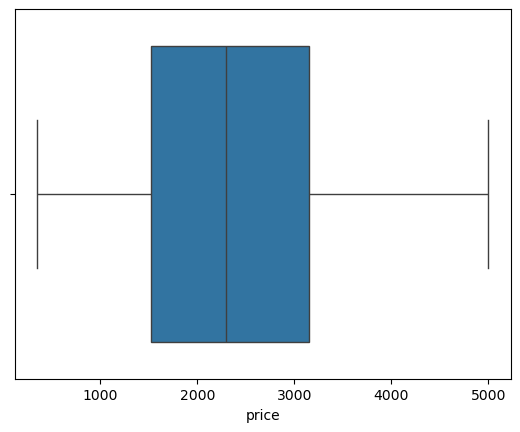

In [11]:
#Code for 'price' field
sns.boxplot(x=newdf['price'])

c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='square'>

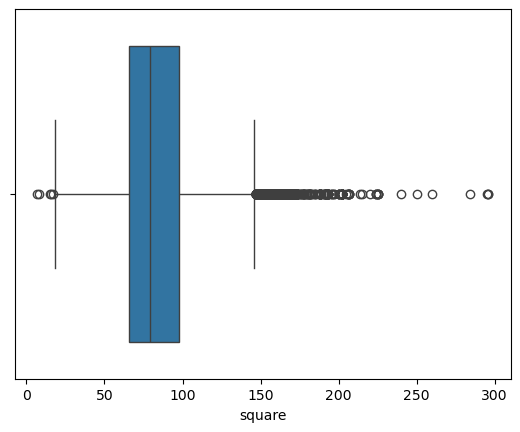

In [12]:
#Code for 'square' field
sns.boxplot(x=newdf['square'])

c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='bedrooms'>

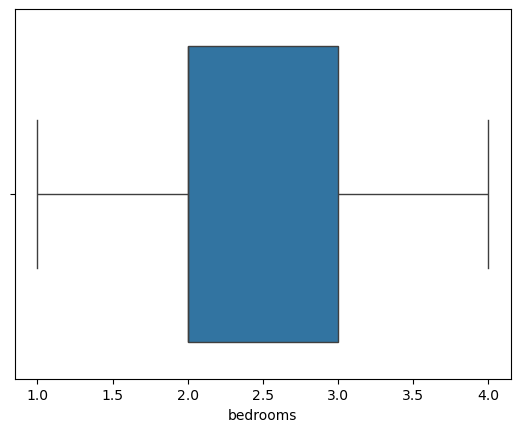

In [13]:
#Code for 'bedrooms' field
sns.boxplot(x=newdf['bedrooms'])

c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='bathrooms'>

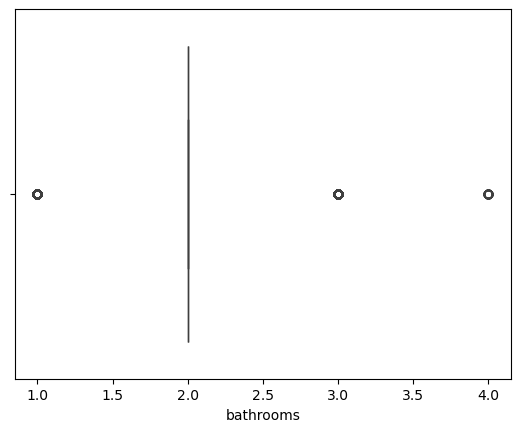

In [14]:
#Code for 'bathrooms' field
sns.boxplot(x=newdf['bathrooms'])

## Vẽ các biểu đồ cho quan hệ giữa các cặp thuộc tính

C:\Users\tonyb\AppData\Local\Temp\ipykernel_15560\1920162332.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')


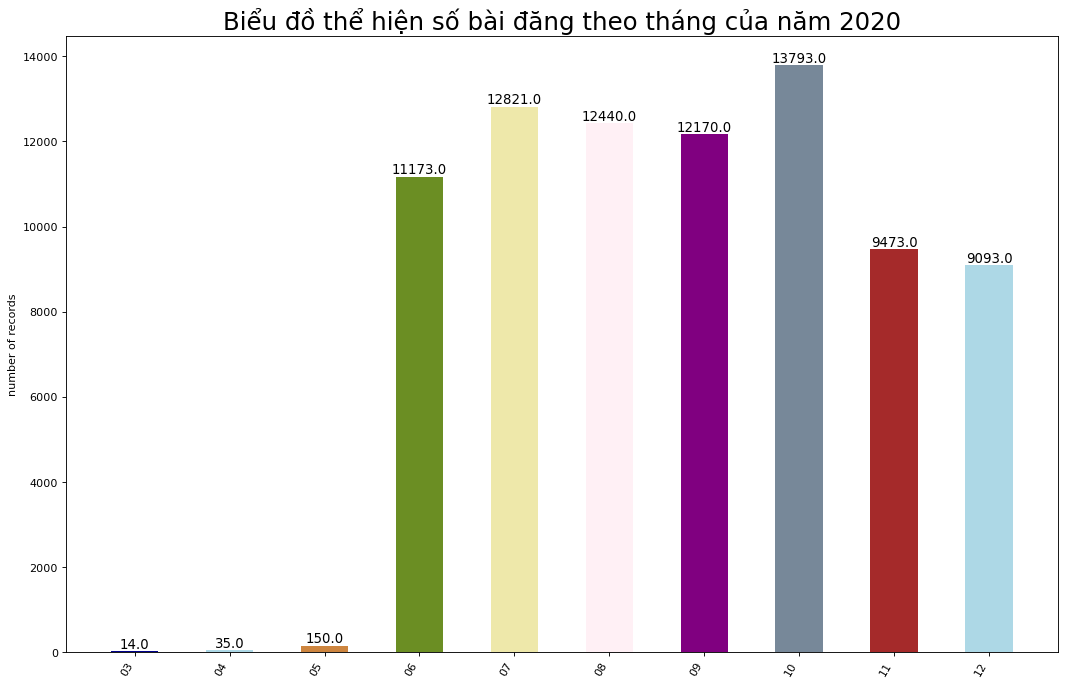

In [15]:
df1 = newdf.groupby('month').size().reset_index(name='number of records')
n = df1['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number of records'], color=c, width=.5)
for i, val in enumerate(df1['number of records'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

* Biểu đồ thể hiện giá nhà đất trung bình theo tháng (VND/m2)

In [3]:
#Tạo bản sao
df = newdf.copy()

In [4]:
df['square'] = df['square'].fillna(df['square'].median())
df['price'] = df['price'].fillna(df['price'].median())
df['price_per_square'] = df['price']/df['square']
df['price_per_square'] = df['price_per_square'].apply(lambda x : round(x, 2))

In [51]:
#avg_price là lưu giá đất trung bình theo tháng
avg_price = df.groupby('month')['price_per_square'].mean().reset_index(name='Average_price_per_square')
avg_price

,month,Average_price_per_square
0,03,26.012857
1,04,23.817429
2,05,26.763467
3,06,28.056227
4,07,28.169849
5,08,28.023843
6,09,28.519168
7,10,28.761500
8,11,29.251052
9,12,29.411492


Text(0.5, 1.0, 'Biểu đồ thể hiện giá đất trung bình theo tháng của năm 2020')

Text(0.5, 1.0, 'Biểu đồ thể hiện giá đất trung bình theo tháng của năm 2020')

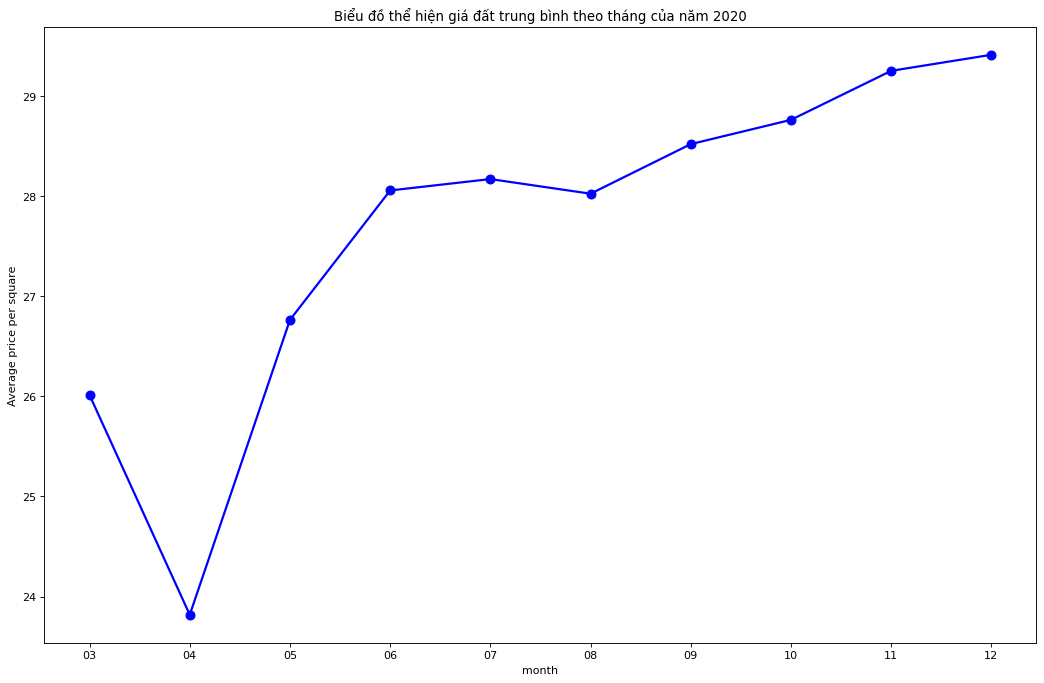

In [20]:
plt.figure(figsize=(16,10), dpi= 80)
plt.plot(avg_price['month'], avg_price['Average_price_per_square'], color='blue', marker='o', linewidth=2, markersize=8)
plt.xlabel('month')
plt.ylabel('Average price per square')
plt.title("Biểu đồ thể hiện giá đất trung bình theo tháng của năm 2020")

* Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)

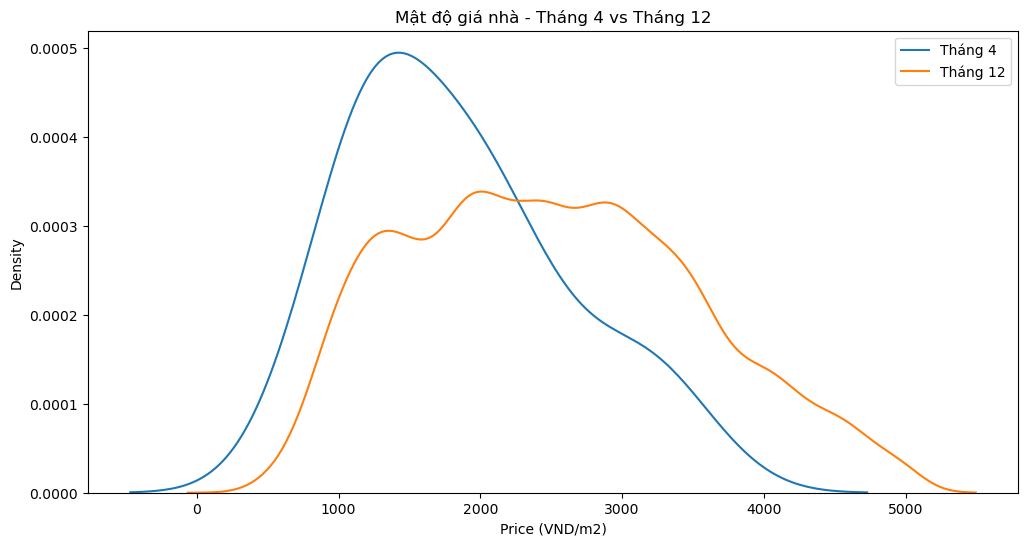

In [13]:
# Lọc dữ liệu tháng 4 và 12
data_months = df[df['month'].isin(['04', '12'])]

# Vẽ density plot
plt.figure(figsize=(12, 6))
sns.kdeplot(data=data_months[data_months['month'] == '04'], x='price', label='Tháng 4')
sns.kdeplot(data=data_months[data_months['month'] == '12'], x='price', label='Tháng 12')
plt.title('Mật độ giá nhà - Tháng 4 vs Tháng 12')
plt.xlabel('Price (VND/m2)')
plt.legend()
plt.show()

* Số lượng bất động sản phân theo số lượng bedrooms

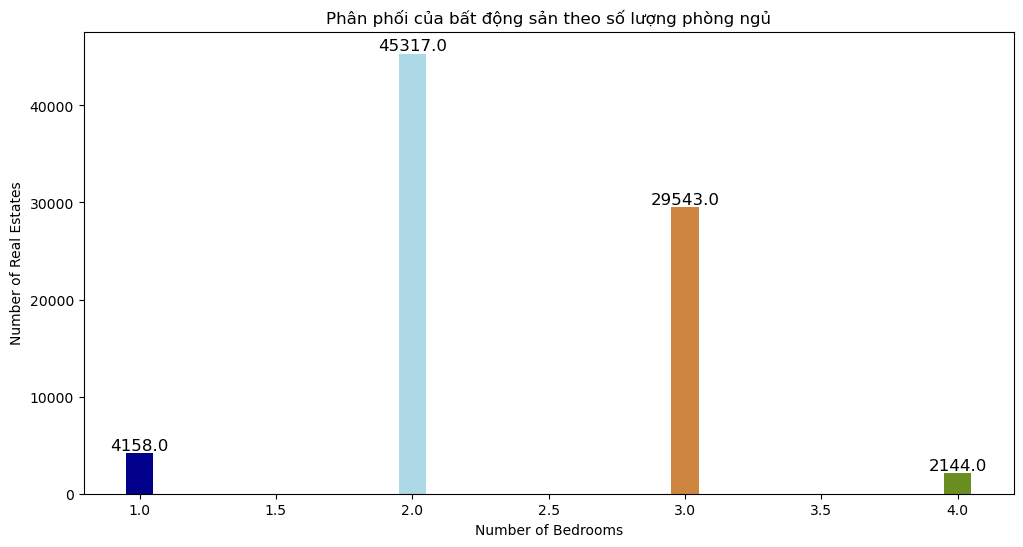

In [56]:
data_bedrooms = df.groupby('bedrooms').size().reset_index(name='Number of real estates')
n = data_bedrooms['bedrooms'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(12, 6))
plt.bar(data_bedrooms['bedrooms'], data_bedrooms['Number of real estates'], color=c, width=.1)
for bedroom, val in zip(data_bedrooms['bedrooms'], data_bedrooms['Number of real estates']):
    plt.text(bedroom, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Real Estates')
plt.title('Phân phối của bất động sản theo số lượng phòng ngủ')
plt.show()

* Giá bất động sản trung bình theo số lượng bedrooms

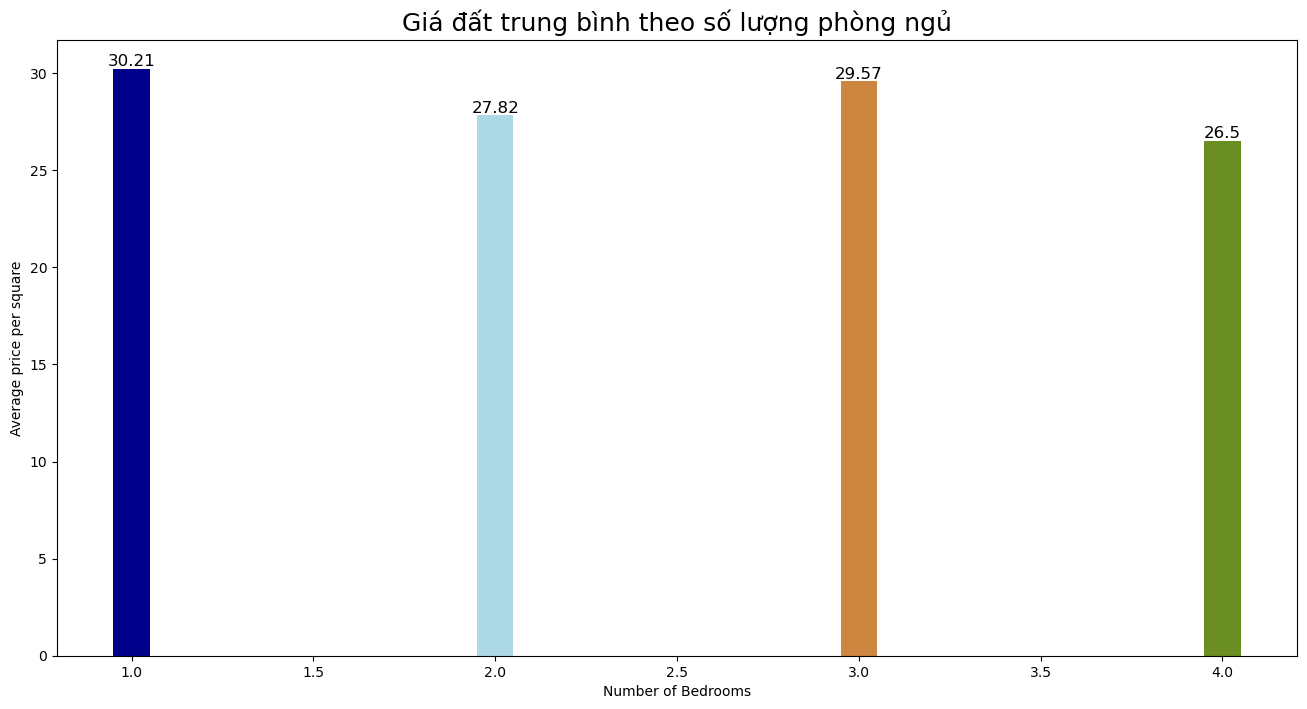

In [69]:
data_bedrooms2 = df.groupby('bedrooms')['price_per_square'].mean().reset_index(name='Average price per square')
data_bedrooms2['Average price per square'] = data_bedrooms2['Average price per square'].apply(lambda x : round(x, 2))
n = data_bedrooms2['bedrooms'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16, 8))
plt.bar(data_bedrooms2['bedrooms'], data_bedrooms2['Average price per square'], color=c, width=.1)
for bedroom, val in zip(data_bedrooms2['bedrooms'], data_bedrooms2['Average price per square']):
    plt.text(bedroom, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.title('Giá đất trung bình theo số lượng phòng ngủ', fontsize=18)
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average price per square')
plt.show()

* Giá nhà đất trung bình theo quận (VND/m2)

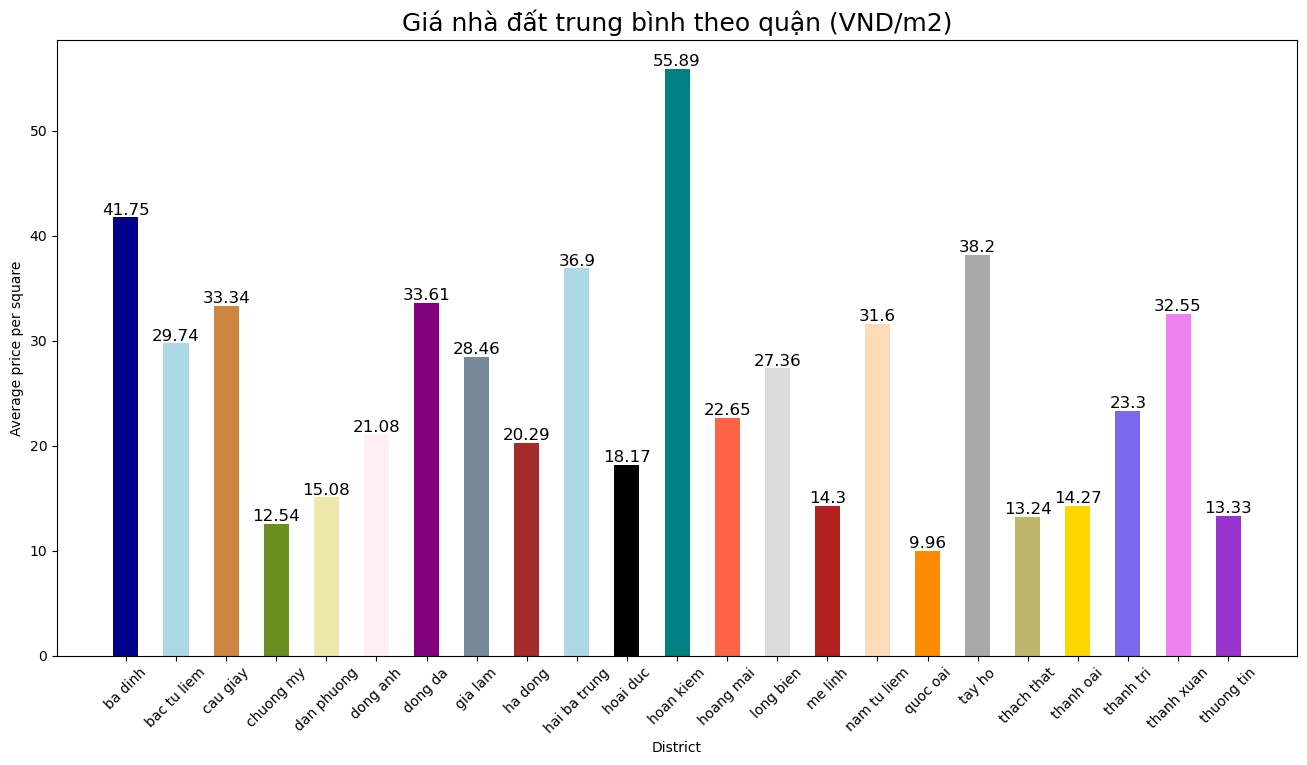

In [71]:
district_price = df.groupby('district')['price_per_square'].mean().reset_index(name='Average price per square')
district_price['Average price per square'] = district_price['Average price per square'].apply(lambda x : round(x, 2))
n = district_price['district'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16, 8))
plt.bar(district_price['district'], district_price['Average price per square'], color=c, width=.5)
for district, val in zip(district_price['district'], district_price['Average price per square']):
    plt.text(district, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.xticks(rotation=45)
plt.xlabel('District')
plt.ylabel('Average price per square')
plt.title('Giá nhà đất trung bình theo quận (VND/m2)', fontsize=18)
plt.show()

* Giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)

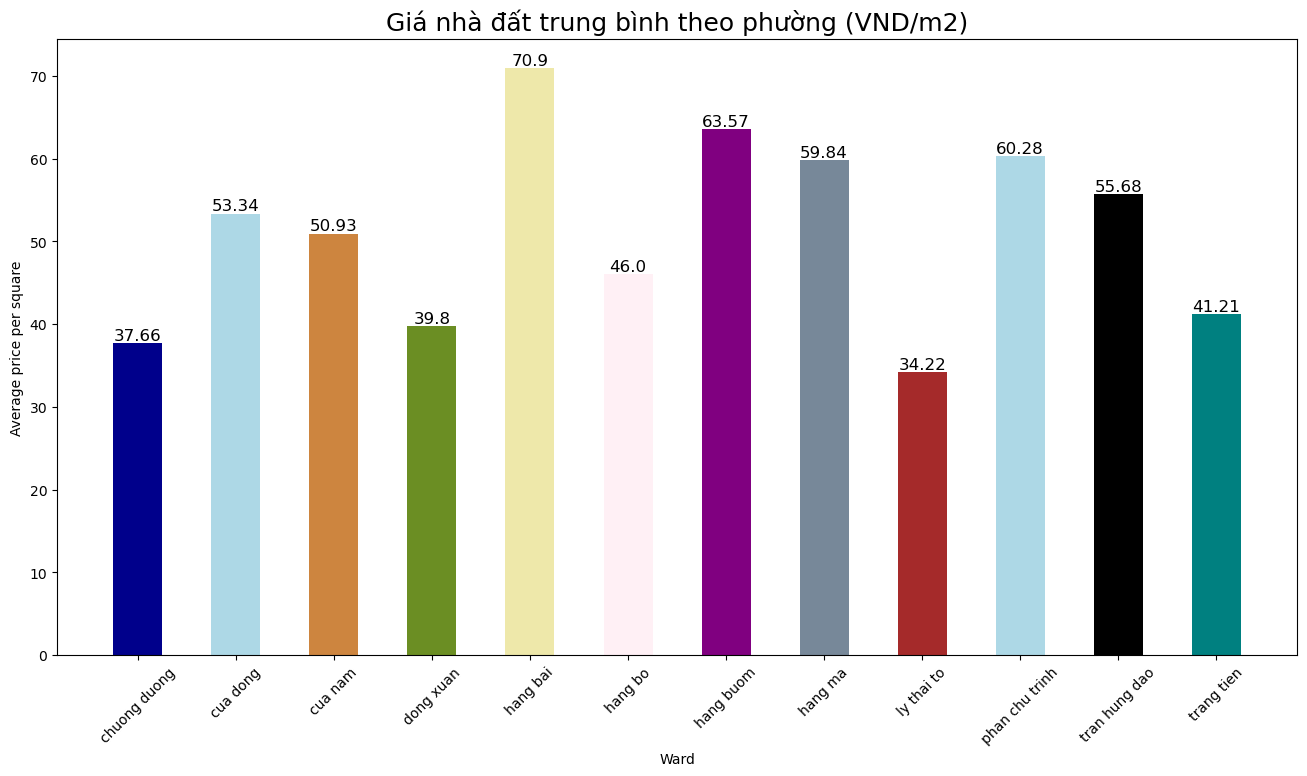

In [75]:
ward_price = df[df['district'] == 'hoan kiem'].groupby('ward')['price_per_square'].mean().reset_index(name='Average price per square')
ward_price['Average price per square'] = ward_price['Average price per square'].apply(lambda x : round(x, 2))
n = ward_price['ward'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16, 8))
plt.bar(ward_price['ward'], ward_price['Average price per square'], color=c, width=.5)
for ward, val in zip(ward_price['ward'], ward_price['Average price per square']):
    plt.text(ward, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.xticks(rotation=45)
plt.xlabel('Ward')
plt.ylabel('Average price per square')
plt.title('Giá nhà đất trung bình theo phường (VND/m2)', fontsize=18)
plt.show()

* Giá nhà đất trung bình theo nhà đầu tư (VND/m2)

In [ ]:
investors_df = df.groupby('investor')['price_per_square'].mean().reset_index(name='Average price per square')
investors_df

,investor,Average price per square
0,Bộ Tham Mưu - Bộ Tư Lệnh Bộ Đội Biên Phòng,25.921071
1,C.T Group,30.881563
2,Công TNHH Bắc Chương Dương,37.109216
3,Công Ty CP Đầu Tư Xây Dựng Và Địa Ốc An Việt ...,29.026667
4,Công ty Booyoung,27.307205
...,...,...
257,Tổng công ty Xây dựng Thanh Hóa - Công ty Cổ phần,48.920229
258,Tổng công ty Đầu tư Phát triển Hạ tầng đô thị ...,32.117112
259,Tổng công ty đầu tư phát triển nhà và đô thị B...,25.951736
260,Vimefulland,36.425000


* Giá nhà đất trung bình theo dự án (VND/m2)

In [ ]:
df2 = df.groupby('project')['price_per_square'].mean().reset_index(name='Average price per square')
df2

,project,Average price per square
0,6th Element,41.882500
1,A10-A14 Nam Trung Yên,29.914300
2,AQH Riverside,25.021667
3,AZ Lâm Viên Complex,27.678333
4,Amber Riverside,34.036061
...,...,...
615,Xuân Phương Garden,21.000000
616,Xuân Phương Residence,25.018485
617,Xuân Phương Tasco,21.938772
618,Yên Hòa Condominium,30.205556


* Giá bất động sản phân bố theo top 10 nhà đầu tư triệu /m2

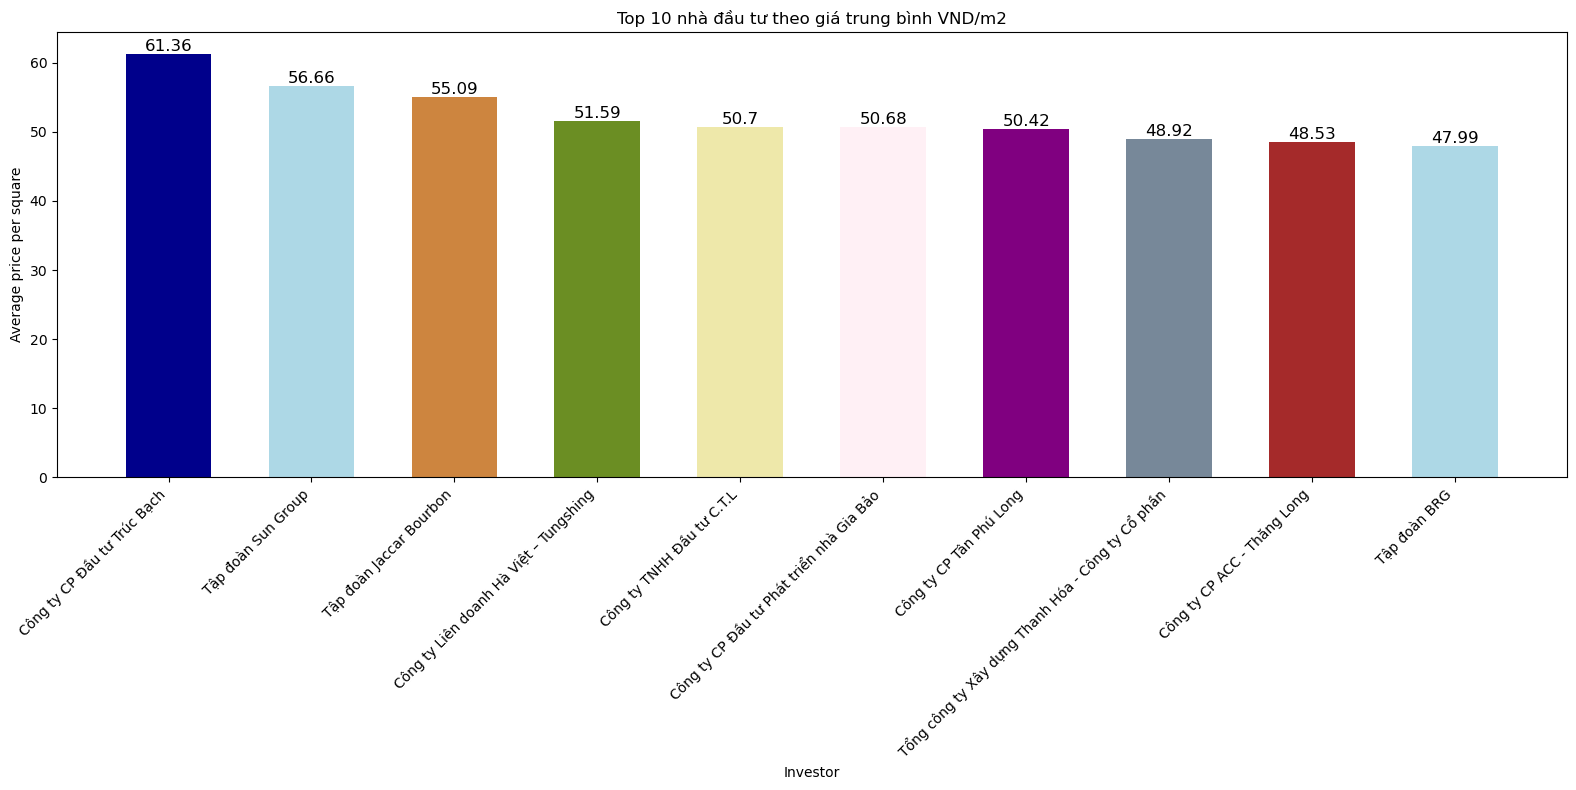

In [85]:
investors_top10 = investors_df.sort_values(by='Average price per square', ascending=False).head(10)
investors_top10['Average price per square'] = investors_top10['Average price per square'].apply(lambda x : round(x, 2))
n = investors_top10.shape[0] + 1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16, 8))
plt.bar(investors_top10['investor'], investors_top10['Average price per square'], color=c, width=.6)
for investor, val in zip(investors_top10['investor'], investors_top10['Average price per square']):
    plt.text(investor, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.xticks(rotation=45, ha='right')
plt.xlabel('Investor')
plt.ylabel('Average price per square')
plt.title('Top 10 nhà đầu tư theo giá trung bình VND/m2')
plt.tight_layout()
plt.show()

* Giá bất động sản phân bố theo top 10 dự án

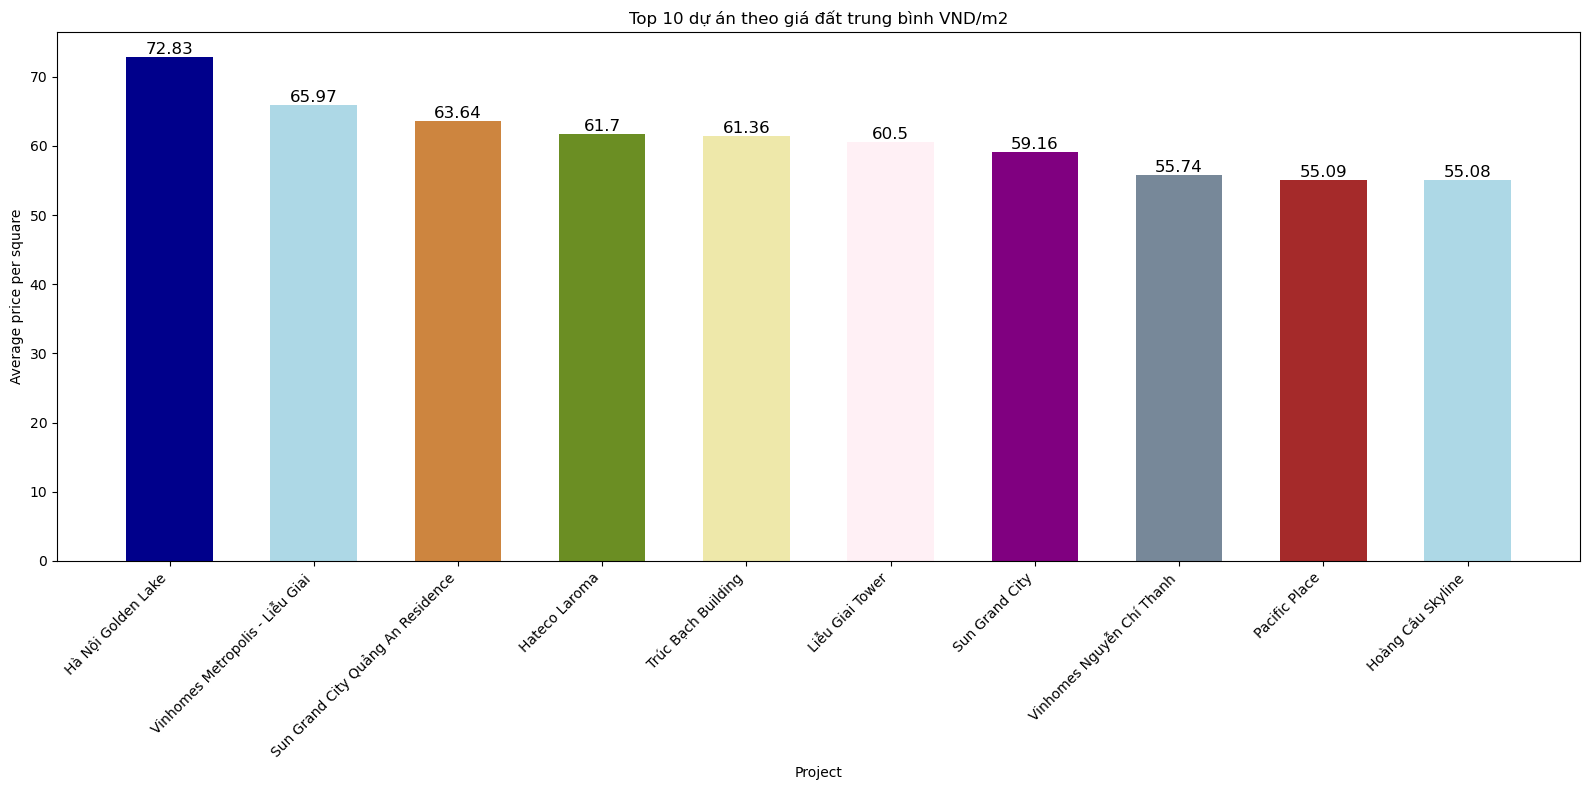

In [86]:
projects_top10 = df2.sort_values(by='Average price per square', ascending=False).head(10)
projects_top10['Average price per square'] = projects_top10['Average price per square'].apply(lambda x : round(x, 2))
n = projects_top10.shape[0] + 1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16, 8))
plt.bar(projects_top10['project'], projects_top10['Average price per square'], color=c, width=.6)
for project, val in zip(projects_top10['project'], projects_top10['Average price per square']):
    plt.text(project, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.xticks(rotation=45, ha='right')
plt.xlabel('Project')
plt.ylabel('Average price per square')
plt.title('Top 10 dự án theo giá đất trung bình VND/m2')
plt.tight_layout()
plt.show()

* Giá nhà đất trung bình theo hướng nhà (VND/m2)

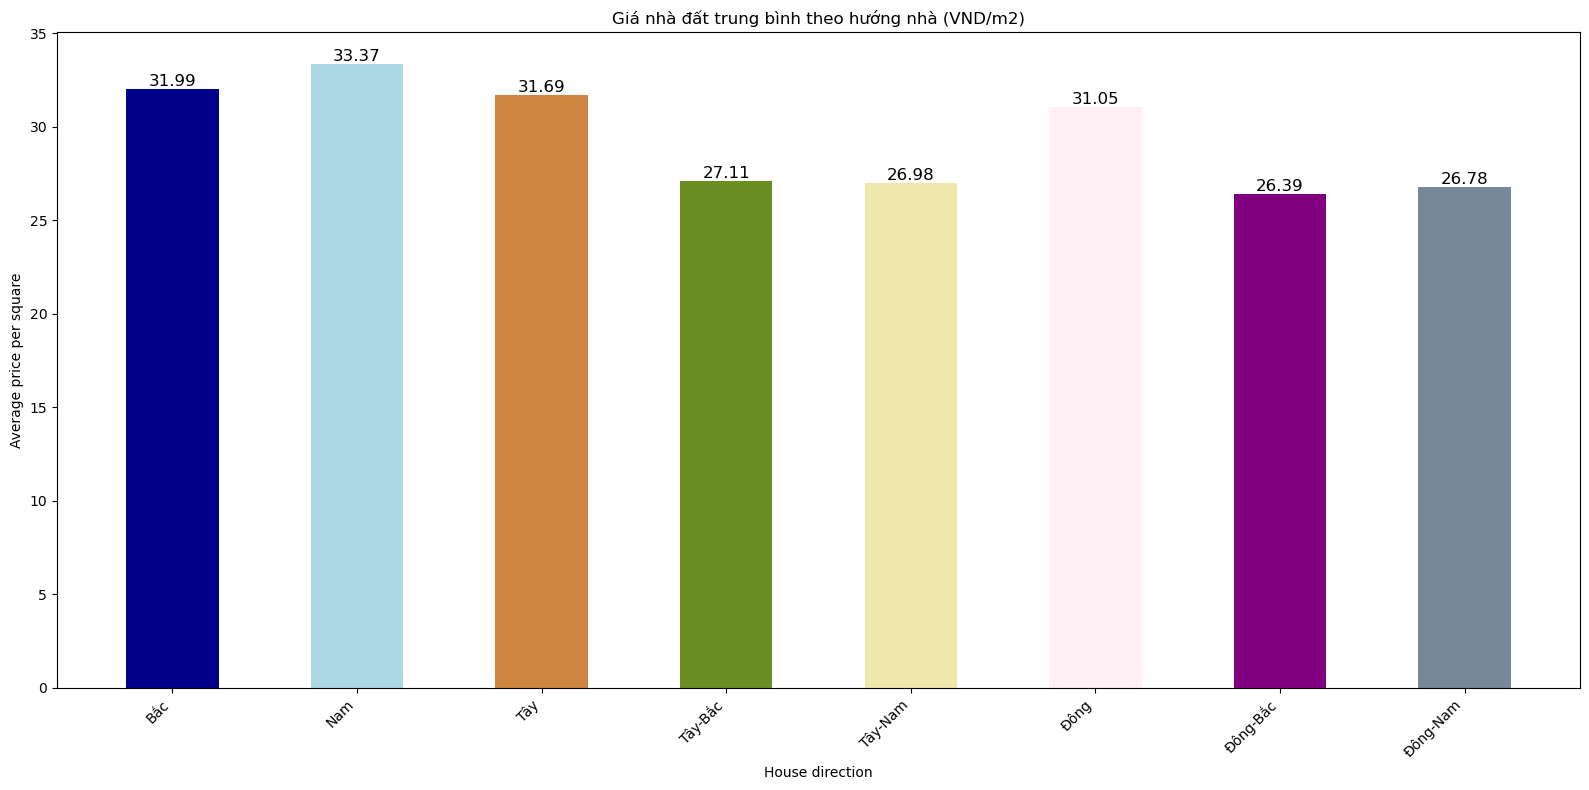

In [88]:
direction_price = df.groupby('direction')['price_per_square'].mean().reset_index(name='Average price per square')
direction_price['Average price per square'] = direction_price['Average price per square'].apply(lambda x: round(x, 2))
n = direction_price.shape[0] + 1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16, 8))
plt.bar(direction_price['direction'], direction_price['Average price per square'], color=c, width=.5)
for direction, val in zip(direction_price['direction'], direction_price['Average price per square']):
    plt.text(direction, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.xticks(rotation=45, ha='right')
plt.xlabel('House direction')
plt.ylabel('Average price per square')
plt.title('Giá nhà đất trung bình theo hướng nhà (VND/m2)')
plt.tight_layout()
plt.show()

## Tương quan giữa các trường thuộc tính

* https://vi.wikipedia.org/wiki/H%E1%BB%87_s%E1%BB%91_t%C6%B0%C6%A1ng_quan

<Axes: >

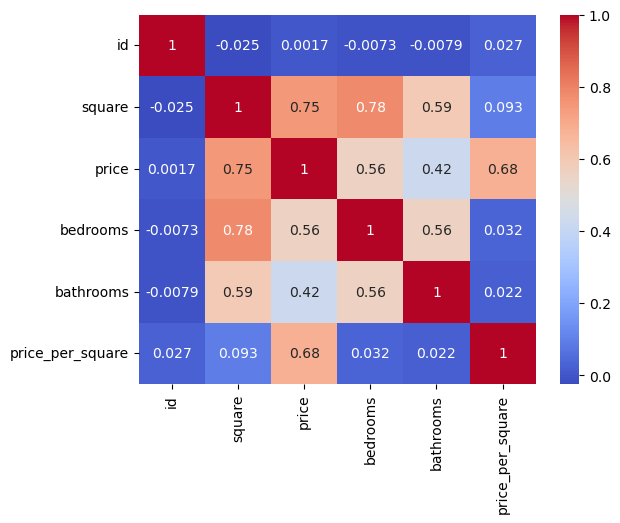

In [ ]:
numeric_columns = ['id', 'square', 'price', 'bedrooms', 'bathrooms', 'price_per_square']
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap='coolwarm')

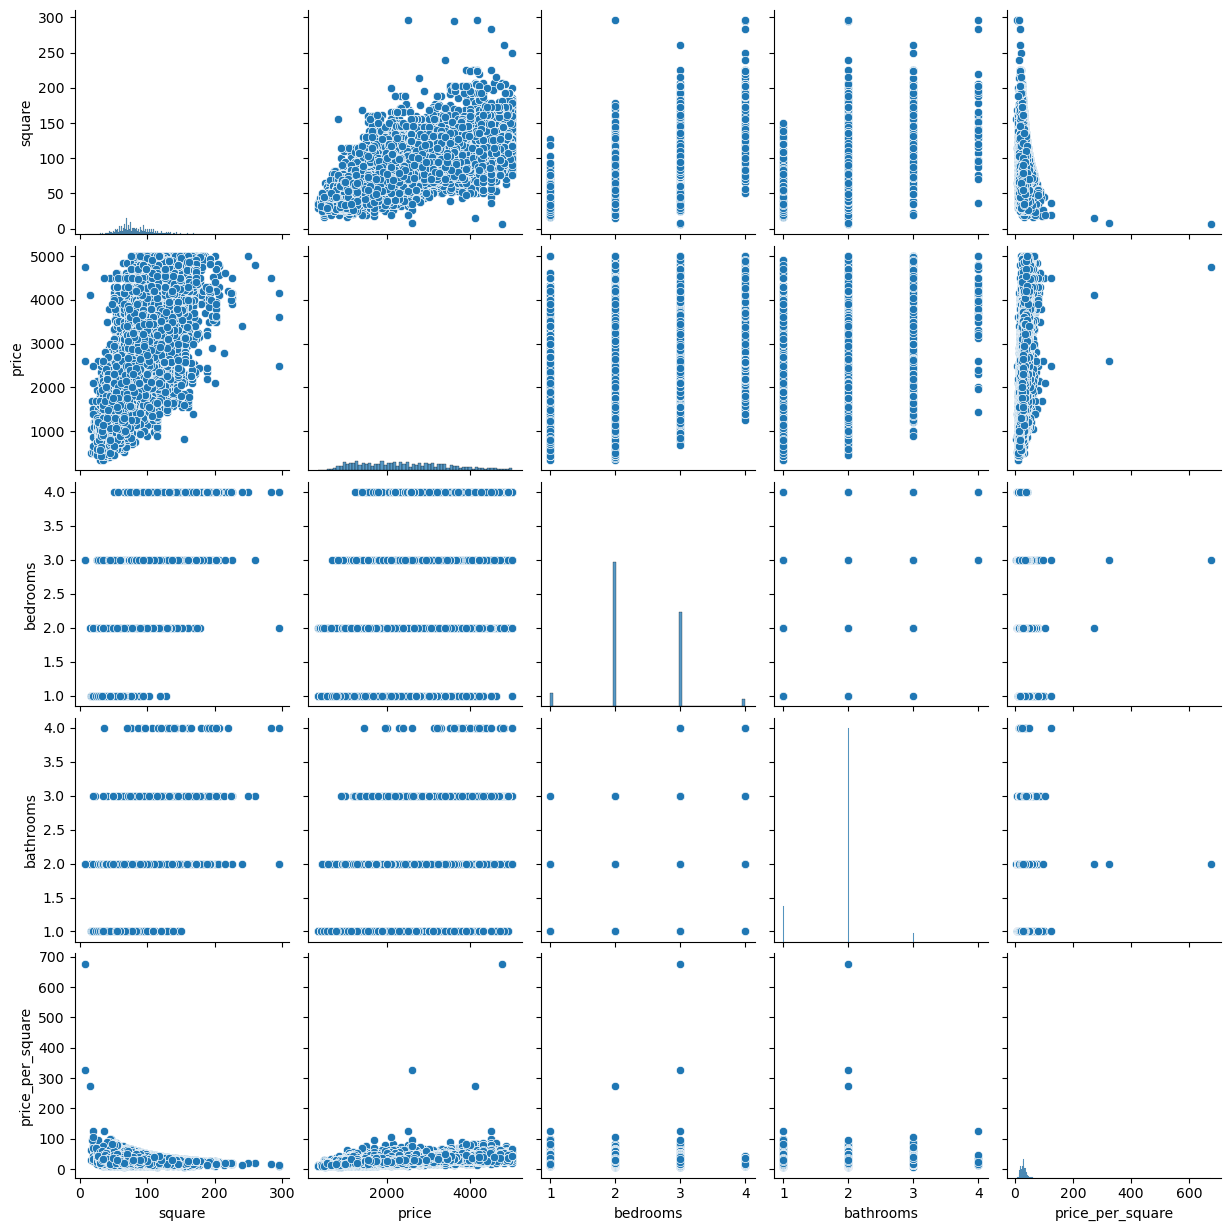

In [95]:
sns.pairplot(df[numeric_columns], kind='scatter')



## Mật độ giá nhà trung bình theo quận 

C:\Users\tonyb\AppData\Local\Temp\ipykernel_12432\3969001015.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x="price_per_square", hue="district", fill=True, common_norm=False, alpha=0.5)
C:\Users\tonyb\AppData\Local\Temp\ipykernel_12432\3969001015.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='District', bbox_to_anchor=(1.05, 1), loc='upper left')


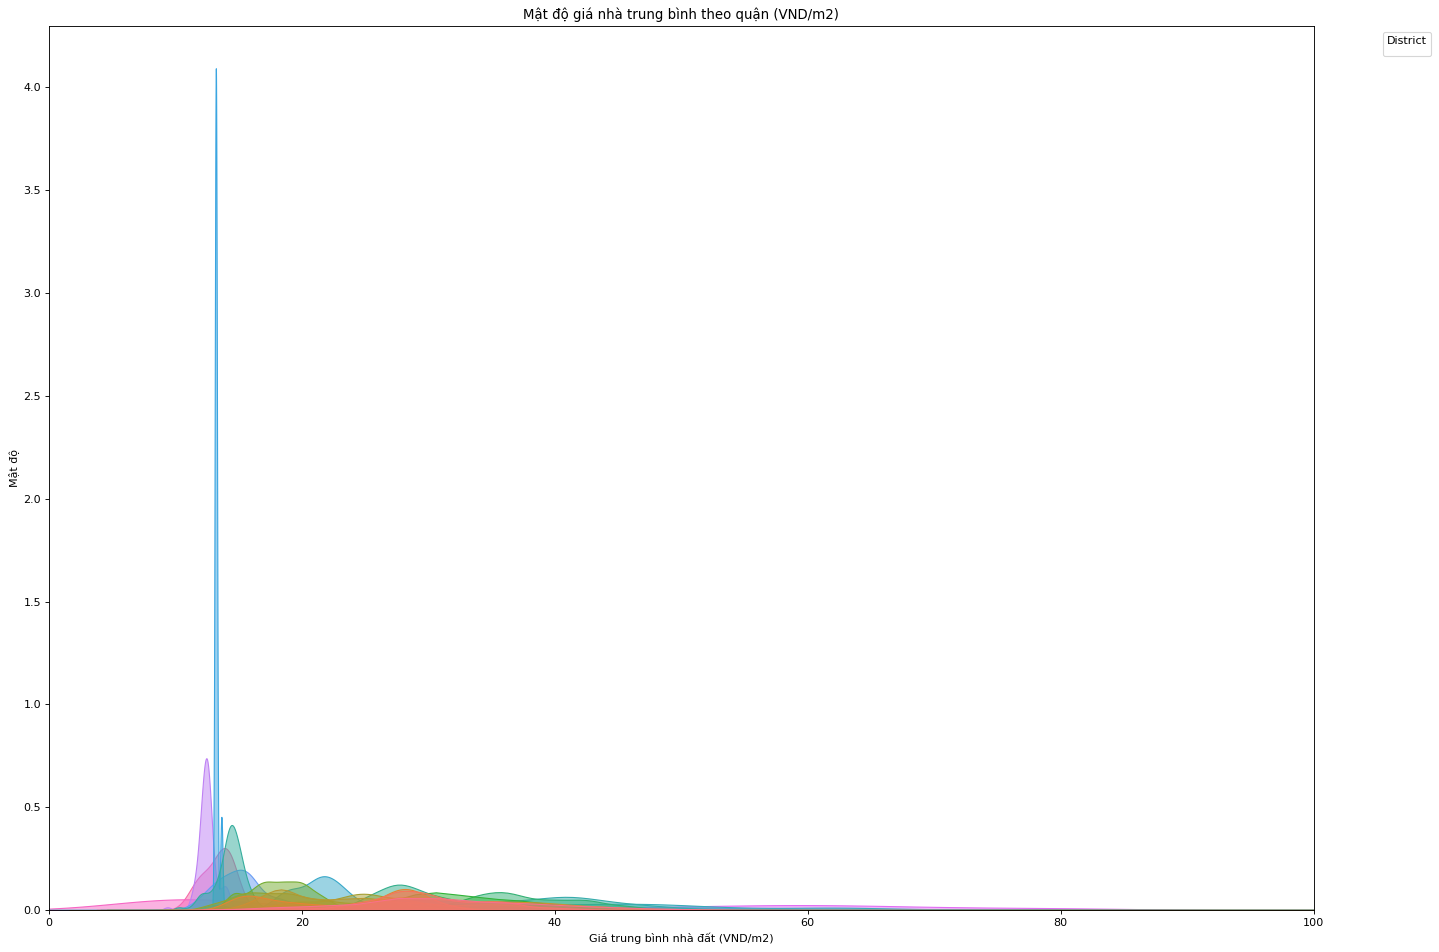

In [8]:
plt.figure(figsize=(18, 12), dpi=80)
sns.kdeplot(data=df, x="price_per_square", hue="district", fill=True, common_norm=False, alpha=0.5)
plt.xlim(0, 100)
plt.title('Mật độ giá nhà trung bình theo quận (VND/m2)')
plt.xlabel('Giá trung bình nhà đất (VND/m2)')
plt.ylabel('Mật độ')
plt.legend(title='District', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


End :))